In [325]:
from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np

from algs.cd_loss2 import CDLoss
from algs.bases import MonomialBasis, BasisSpec, ChebyshevBasis
from algs.cd_poly import CDPolynomial
from sklearn.random_projection import GaussianRandomProjection

In [326]:
X, t = make_swiss_roll(n_samples=1000)
y = t < 7

In [327]:
X.shape, t.shape

((1000, 3), (1000,))

In [328]:
t.min()

4.752489945659731

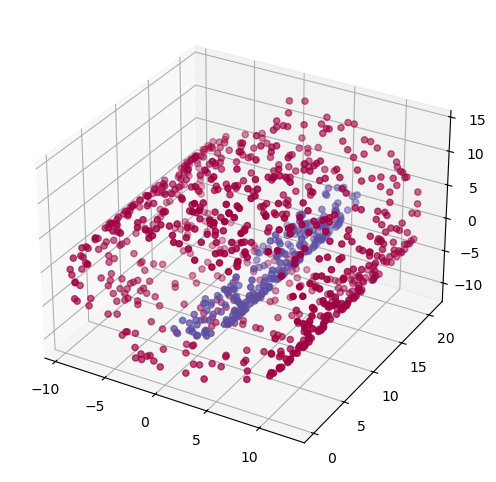

In [330]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=y, cmap=plt.cm.Spectral)
plt.show()

In [331]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(3, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 2),
            nn.BatchNorm1d(num_features=2)
            #nn.LayerNorm(2, elementwise_affine=True)
            #nn.Tanh()
        )
        self.dec = nn.Sequential(
            nn.Linear(2, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 3)
        )

    def forward(self, x):
        z = self.enc(x)
        x_rec = self.dec(z)
        return x_rec, z
    
    @torch.no_grad()
    def encode(self, x):
        return self.enc(x)

In [670]:
x = torch.from_numpy(X.astype(np.float32))

In [753]:
d = 5

model = Model()
opt = torch.optim.SGD(model.parameters(), lr=1e-2)
p = CDLoss(degree=d, n_vars=2, eps=1e-2, basis='cheb')
dl = DataLoader(x[y], batch_size=len(x))

In [763]:
print(y.sum())

235


torch.Size([21, 21])


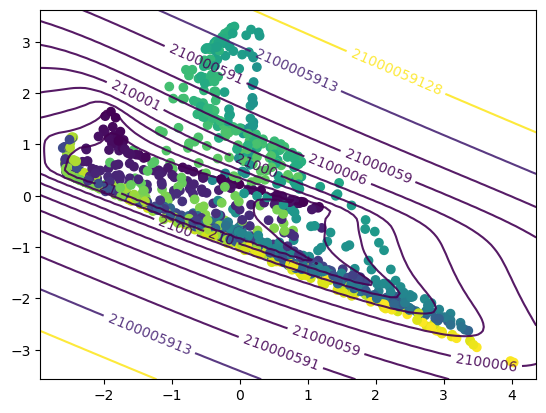

In [764]:
_,z = model(x)
plt.scatter(*z.detach().numpy().T, c=t)

q = CDPolynomial(z[y].detach().numpy(), degree=d)
print(q.M.shape)
q.plot(plt.gca())

_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 21 is not positive-definite).

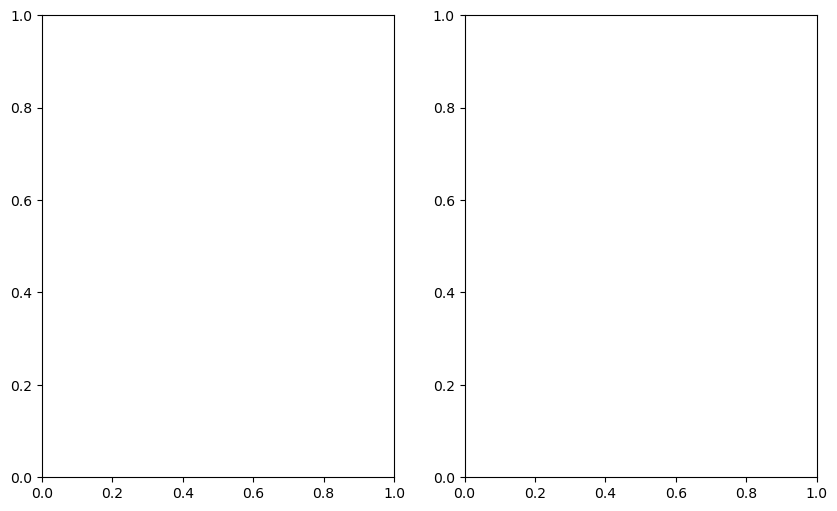

In [766]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 6))

bs = BasisSpec(n_vars = 2, degree=1)
cheb = ChebyshevBasis(bs)

for i in range(10):
    p.update_buffer(dl, model, device='cpu')

    x_rec, z = model(x)

    v = cheb.transform(z[y])

    if i == 0 or i == 3:
      ax[0 if i==0 else 1].scatter(*z.detach().T, c=y)

    rec_loss = F.mse_loss(x_rec, x)
    in_loss = F.relu(p(z[y]) - 15).mean()
    out_loss = F.relu(21 - p(z[~y])).mean()
    orth_loss = ((v.T @ v / len(z[y]) - torch.eye(3)) ** 2).mean()
    #in_loss = (z[y] ** 2).mean()
    #out_loss = -(z[~y] ** 2).mean()
    #in_loss = (z[y] ** 2).mean()
    loss = rec_loss + 1. * out_loss #+ .6 * orth_loss

    opt.zero_grad()
    loss.backward()
    opt.step()

    print(loss.detach().item(),
          rec_loss.detach().item(),
          out_loss.detach().numpy()
    )
    print(f'{torch.linalg.cond(p.M_buf):e}')
    print(f'Orth: {orth_loss}')

In [ ]:
    out_loss = -torch.log(p(z[~y])).mean()
    #orth_loss = ((v.T @ v / len(z[y]) - torch.eye(10)) ** 2).mean()
    #in_loss = (z[y] ** 2).mean()
    #out_loss = -(z[~y] ** 2).mean()
    #in_loss = (z[y] ** 2).mean()
    loss = 1 * out_loss + 1. * orth_loss

    opt.zero_grad()
    loss.backward()
    opt.step()

    print(loss.detach().item(),
          orth_loss.detach().numpy(),
          out_loss.detach().numpy()
    )
    print(f'{torch.linalg.cond(p.M_buf):e}')

In [648]:
z_rec.shape

torch.Size([1000, 3])